# Simulating Two Algorithmic Decision-Making Systems Managing a $100 Portfolio

## Imports

In [22]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

## Load Data

In [23]:
tickers = [
    "AAPL",   # stable large-cap tech
    "MSFT",   # stable growth + defensive tech
    "NVDA",   # high growth / high volatility
    "AMZN",   # consumer + tech exposure
    "JPM",    # financial sector (non-tech)
    "JNJ",    # defensive healthcare
    "XOM",    # energy exposure (cyclical hedge)
    "SPY"     # broad market baseline
]
data = yf.download(tickers, start="2020-01-01")["Close"]
data = data.dropna()

[*********************100%***********************]  8 of 8 completed


## Simulator

In [24]:
class Simulator:
    def __init__(self, prices, cash=100, fee=0.001, max_weight=0.5):
        self.prices = prices
        self.cash = cash
        self.initial_cash = cash
        self.fee = fee
        self.max_weight = max_weight
        
        self.holdings = {col: 0.0 for col in prices.columns}
        self.history = []

    def value(self, date):
        prices = self.prices.loc[date]
        holdings_value = sum(self.holdings[a] * prices[a] for a in self.holdings)
        return self.cash + holdings_value

    def rebalance(self, date, weights):
        prices = self.prices.loc[date]
        total_value = self.value(date)

        # --- Apply max weight constraint ---
        weights = {k: min(v, self.max_weight) for k, v in weights.items()}
        total_w = sum(weights.values())
        if total_w > 0:
            weights = {k: v / total_w for k, v in weights.items()}

        # --- Sell everything ---
        for a in self.holdings:
            if self.holdings[a] > 0:
                sell_value = self.holdings[a] * prices[a] * (1 - self.fee)
                self.cash += sell_value
                self.holdings[a] = 0

        # --- Buy new allocations ---
        for a, w in weights.items():
            allocation = total_value * w
            price = prices[a]
            
            if allocation > 0:
                shares = allocation / price
                cost = shares * price * (1 + self.fee)

                if cost <= self.cash:
                    self.holdings[a] += shares
                    self.cash -= cost

    def run(self, strategy, rebalance_freq=5):
        for i, date in enumerate(self.prices.index):

            if i % rebalance_freq == 0:
                weights = strategy(date, self.prices.iloc[:i+1])
                self.rebalance(date, weights)

            self.history.append(self.value(date))

        return pd.Series(self.history, index=self.prices.index)

## Strategies

In [25]:
# Momentum (improved)
def momentum(date, prices):
    returns = prices.pct_change().iloc[-20:]
    
    # mean return adjusted by volatility
    mean_ret = returns.mean()
    vol = returns.std()
    
    score = mean_ret / (vol + 1e-8)
    score = score.clip(lower=0)

    if score.sum() == 0:
        return {a: 1/len(score) for a in score.index}

    weights = score / score.sum()
    return weights.to_dict()


# Equal Weight (baseline)
def equal(date, prices):
    n = len(prices.columns)
    return {a: 1/n for a in prices.columns}

## Run Simulation

In [26]:
sim1 = Simulator(data.copy(), cash=100)
sim2 = Simulator(data.copy(), cash=100)

res1 = sim1.run(momentum)
res2 = sim2.run(equal)

## METRICS

In [27]:
def compute_metrics(series):
    returns = series.pct_change().dropna()
    
    total_return = series.iloc[-1] / series.iloc[0] - 1
    
    ann_factor = 252
    volatility = returns.std() * np.sqrt(ann_factor)
    
    sharpe = (returns.mean() * ann_factor) / (returns.std() * np.sqrt(ann_factor))
    
    drawdown = (series / series.cummax() - 1).min()
    
    calmar = total_return / abs(drawdown) if drawdown != 0 else np.nan

    return {
        "Total Return": total_return,
        "Volatility": volatility,
        "Sharpe": sharpe,
        "Max Drawdown": drawdown,
        "Calmar": calmar
    }

m1 = compute_metrics(res1)
m2 = compute_metrics(res2)

## Table Output

In [28]:
from tabulate import tabulate

def pct(x):
    return f"{x*100:.2f}%"

table = [
    ["Momentum", pct(m1["Total Return"]), pct(m1["Volatility"]), f"{m1['Sharpe']:.2f}", pct(m1["Max Drawdown"]), f"{m1['Calmar']:.2f}"],
    ["Equal Weight", pct(m2["Total Return"]), pct(m2["Volatility"]), f"{m2['Sharpe']:.2f}", pct(m2["Max Drawdown"]), f"{m2['Calmar']:.2f}"],
]

headers = ["Strategy", "Total Return", "Volatility", "Sharpe", "Max Drawdown", "Calmar"]

print(tabulate(table, headers=headers))

Strategy      Total Return    Volatility      Sharpe  Max Drawdown      Calmar
------------  --------------  ------------  --------  --------------  --------
Momentum      87.03%          18.64%            0.63  -28.24%             3.08
Equal Weight  111.22%         21.10%            0.67  -32.75%             3.4


## Visualization

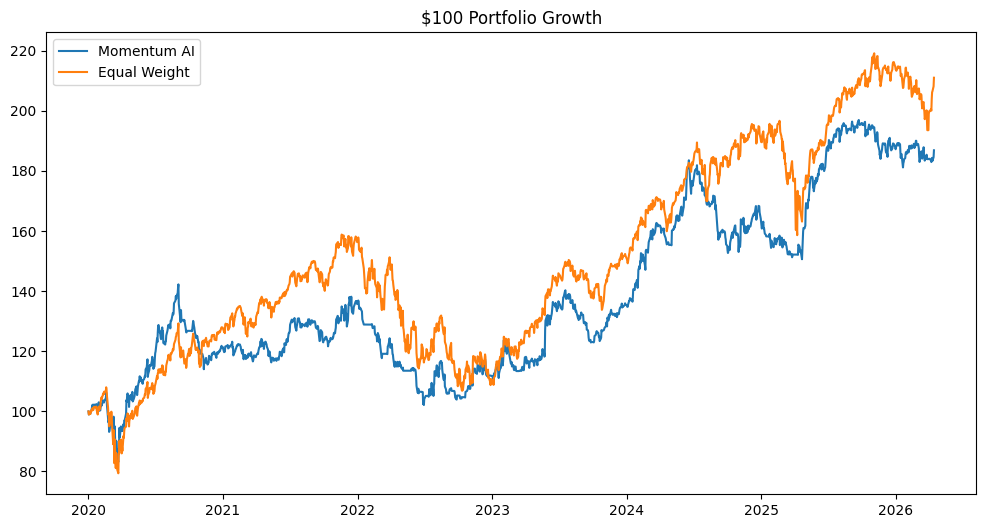

In [30]:
plt.figure(figsize=(12, 6))
plt.plot(res1, label="Momentum AI")
plt.plot(res2, label="Equal Weight")
plt.title("$100 Portfolio Growth")
plt.legend()
plt.savefig("portfolio_growth.png")
plt.show()